In [2]:
# load necessary libraries for network anaylysis
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os as os
import powerlaw
import mygene
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import matplotlib.cm as cm
import matplotlib.colors as colors
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from matplotlib.patches import Ellipse
from matplotlib.patches import Patch

In [3]:
# load the data tab separated txtile

file_path = r"/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/output_text_files/05_edgelist/turquoise/CytoscapeInput-edges-turquoise.txt"

data = pd.read_csv(file_path,sep='\t')

#print the head
print(data.head())

             fromNode              toNode    weight   direction  \
0  ENSMUSG00000000056  ENSMUSG00000002489  0.084921  undirected   
1  ENSMUSG00000000056  ENSMUSG00000003949  0.054290  undirected   
2  ENSMUSG00000000056  ENSMUSG00000007877  0.063580  undirected   
3  ENSMUSG00000000056  ENSMUSG00000009376  0.058055  undirected   
4  ENSMUSG00000000056  ENSMUSG00000019933  0.050479  undirected   

          fromAltName           toAltName  
0  ENSMUSG00000000056  ENSMUSG00000002489  
1  ENSMUSG00000000056  ENSMUSG00000003949  
2  ENSMUSG00000000056  ENSMUSG00000007877  
3  ENSMUSG00000000056  ENSMUSG00000009376  
4  ENSMUSG00000000056  ENSMUSG00000019933  


## consider edges with correlation values greater than 0.05

In [4]:
# Count edges before filtering
num_edges_before = len(data)
print(f"Number of edges before filtering: {num_edges_before}")


# Filter edges where correlation is greater than 0.1
filtered_df = data[data['weight'] > 0.05]

# Count edges after filtering
num_edges_after = len(filtered_df)
print(f"Number of edges after filtering: {num_edges_after}")

# Print the head of the filtered DataFrame
print("Head of the filtered data:")
print(filtered_df.head())

Number of edges before filtering: 16899
Number of edges after filtering: 16899
Head of the filtered data:
             fromNode              toNode    weight   direction  \
0  ENSMUSG00000000056  ENSMUSG00000002489  0.084921  undirected   
1  ENSMUSG00000000056  ENSMUSG00000003949  0.054290  undirected   
2  ENSMUSG00000000056  ENSMUSG00000007877  0.063580  undirected   
3  ENSMUSG00000000056  ENSMUSG00000009376  0.058055  undirected   
4  ENSMUSG00000000056  ENSMUSG00000019933  0.050479  undirected   

          fromAltName           toAltName  
0  ENSMUSG00000000056  ENSMUSG00000002489  
1  ENSMUSG00000000056  ENSMUSG00000003949  
2  ENSMUSG00000000056  ENSMUSG00000007877  
3  ENSMUSG00000000056  ENSMUSG00000009376  
4  ENSMUSG00000000056  ENSMUSG00000019933  


## set a base directory for the output files

In [5]:
base_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/outputs/network_analysis/turquoise"

In [6]:
# Manually create symbol → community dictionary
gene_to_community = {
    "Atp8a1": "Community 7",
    "Car3": "Community 4",
    "Nr1d2": "Community 6",
    "4930471C04Rik": "Community 4",
    "Cib2": "Community 7",
    "Gm40841": "Community 6",
    "Tiam1": "Community 5",
    "Tbc1d1": "Community 1",
    "Chrnb1": "Community 3",
    "Vps13a": "Community 7",
    "Mreg": "Community 5",
    "Rab11b": "Community 4",
    "Mrln": "Community 4",
    "Ttll7": "Community 3",
    "Dcaf4": "Community 4",
    "Gm11734": "Community 5",
    "Oplah": "Community 5",
    "Mylk4": "Community 7",
    "Aebp1": "Community 1",
    "BC004004": "Community 3",
    "Cpne2": "Community 7",
    "Pla2g7": "Community 3",
    "Sorbs3": "Community 1",
    "Slc9a2": "Community 3",
    "Igf2bp2": "Community 6",
    "Per3": "Community 6",
    "Sucla2": "Community 5",
    "Tcap": "Community 6"
}

In [7]:

# Create graph
G = nx.Graph()
for _, row in filtered_df.iterrows():
    G.add_edge(row['fromNode'], row['toNode'], weight=row['weight'])

# Step 1: Convert all Ensembl IDs to gene symbols
all_nodes = list(G.nodes())

print(f"Total number of nodes to query: {len(all_nodes)}")
mg = mygene.MyGeneInfo()
query_result = mg.querymany(all_nodes, scopes='ensembl.gene', fields='symbol', species='mouse')

# Step 2: Build mapping dictionary
id_to_symbol = {item['query']: item.get('symbol', item['query']) for item in query_result}

# Step 3: Relabel nodes in the main graph
nx.relabel_nodes(G, id_to_symbol, copy=False)

# Step 4: Compute WEIGHTED degree (node strength)
weighted_degree_dict = dict(G.degree(weight="weight"))

degree_df = pd.DataFrame(
    weighted_degree_dict.items(),
    columns=["Node", "Degree"]
)

degree_df = degree_df.sort_values(by="Degree", ascending=False)

print(degree_df)
print(len(G.nodes()))


# Step 5: Save all and top 25

degree_df.to_csv(os.path.join(base_path, "all_nodes_by_degree.csv"), index=False, sep='\t', encoding='utf-8')
print("All nodes saved to all_nodes_by_degree.csv")

# Compute the degree threshold for the top 10%
threshold = degree_df['Degree'].quantile(0.95)

#print the threshold
print(f"Degree threshold for top 5% nodes: {threshold}")
# Filter only nodes whose degree is >= threshold
top_5_percent_df = degree_df[degree_df['Degree'] >= threshold]

print(top_5_percent_df)

# Save to file
output_path = os.path.join(base_path, "top_5_percent_nodes_by_degree.csv")
top_5_percent_df.to_csv(output_path, index=False, sep='\t', encoding='utf-8')

print("Top 5% nodes saved to top_5_percent_nodes_by_degree.csv")

# Step 6: Extract subgraph
top_5_percent_nodes = list(top_5_percent_df['Node'])
subgraph = G.subgraph(top_5_percent_nodes).copy()


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Total number of nodes to query: 553


1 input query terms found no hit:	['ENSMUSG00000085133']


       Node     Degree
543   Nr1d2  46.738940
530  Tbc1d1  38.586212
535    Car3  38.314104
525  Atp8a1  37.833206
524    Mreg  33.586288
..      ...        ...
27     Maoa   0.051269
21   Eif4e2   0.050926
300   Wdr76   0.050774
47     Ezh2   0.050476
17    Tpd52   0.050221

[553 rows x 2 columns]
553
All nodes saved to all_nodes_by_degree.csv
Degree threshold for top 5% nodes: 21.964986735591943
              Node     Degree
543          Nr1d2  46.738940
530         Tbc1d1  38.586212
535           Car3  38.314104
525         Atp8a1  37.833206
524           Mreg  33.586288
512        Gm40841  32.312006
520         Vps13a  31.312802
551          Tiam1  31.219876
523         Chrnb1  31.127869
514        Gm11734  31.006030
541         Sorbs3  29.598264
539          Oplah  29.103882
500          Ttll7  29.026598
549           Tcap  28.344595
531           Per3  27.837144
521          Mylk4  27.382307
545          Aebp1  27.315129
527          Cpne2  25.843978
513  4930471C04Rik  25.769516

In [8]:
# Assign community attribute to each node in subgraph
for node in subgraph.nodes():
    if node in gene_to_community:
        subgraph.nodes[node]['community'] = gene_to_community[node]
    else:
        subgraph.nodes[node]['community'] = "Unknown"

In [26]:
print(subgraph)

Graph with 28 nodes and 378 edges


In [27]:
print(top_5_percent_nodes)
print(len(top_5_percent_nodes))

['Nr1d2', 'Tbc1d1', 'Car3', 'Atp8a1', 'Mreg', 'Gm40841', 'Vps13a', 'Tiam1', 'Chrnb1', 'Gm11734', 'Sorbs3', 'Oplah', 'Ttll7', 'Tcap', 'Per3', 'Mylk4', 'Aebp1', 'Cpne2', '4930471C04Rik', 'Igf2bp2', 'Slc9a2', 'Sucla2', 'Cib2', 'Mrln', 'BC004004', 'Dcaf4', 'Pla2g7', 'Rab11b']
28


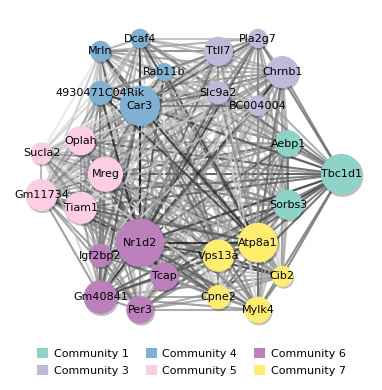

In [14]:
# Get unique communities
communities = list(set(nx.get_node_attributes(subgraph, 'community').values()))

# Color map for communities
color_map = {comm: i for i, comm in enumerate(communities)}

# Assign colors
node_colors = [
    color_map[subgraph.nodes[node]['community']]
    for node in subgraph.nodes()
]

pos = {}
communities = sorted(communities)  # for consistent order

# Large circle positions for communities
angle_step = 2 * np.pi / len(communities)
radius = 5  # radius of big circle

for i, comm in enumerate(communities):

    nodes_in_comm = [n for n in subgraph.nodes()
                     if subgraph.nodes[n]['community'] == comm]

    sub = subgraph.subgraph(nodes_in_comm)

    # small circular layout inside each community
    sub_pos = nx.circular_layout(sub, scale=1.5)

    # compute center of this community on big circle
    theta = i * angle_step
    center_x = radius * np.cos(theta)
    center_y = radius * np.sin(theta)

    # shift small circle to its community center
    for node, (x, y) in sub_pos.items():
        pos[node] = (x + center_x, y + center_y)
# -------------------------
# 1. Node WEIGHTED degree → normalized
# -------------------------
weighted_degrees = dict(G.degree(subgraph.nodes(), weight="weight"))

deg_vals = np.array(
    [weighted_degrees[n] for n in subgraph.nodes()]
).reshape(-1, 1)

scaler = MinMaxScaler()
deg_norm = scaler.fit_transform(deg_vals).flatten()

node_sizes = 150 + deg_norm * 1000

# -------------------------
# Community-based node colors
# -------------------------
communities = sorted(set(nx.get_node_attributes(subgraph, 'community').values()))

# Create stable mapping community → color index
community_to_idx = {comm: i for i, comm in enumerate(communities)}

node_list = list(subgraph.nodes())

node_colors = [
    community_to_idx[subgraph.nodes[n]['community']]
    for n in node_list
]

# Use a qualitative colormap (better than tab10 if many communities)
node_cmap = plt.cm.Set3 # or plt.cm.tab10

# -------------------------
# 2. Edge colors from weights
# -------------------------
edges = list(subgraph.edges(data=True))
edge_weights = np.array([d.get("weight", 0) for _, _, d in edges])

edge_norm = colors.Normalize(edge_weights.min(), edge_weights.max())
edge_cmap = cm.binary
edge_colors = edge_cmap(edge_norm(edge_weights))


# -------------------------
# 3. Plot (Image 1 Style)
# -------------------------
fig, ax = plt.subplots(figsize=(4, 4))

# ---- SHADOW LAYER ----
shadow_offset = np.array([0.05, -0.075])
shadow_pos = {k: v + shadow_offset for k, v in pos.items()}
shadow_sizes = [s * 1.12 for s in node_sizes]

nx.draw_networkx_nodes(
    subgraph,
    shadow_pos,
    node_size=shadow_sizes,
    node_color="black",
    alpha=0.25,
    linewidths=0,
    ax=ax
)

# ---- EDGES (colored by weight) ----
nx.draw_networkx_edges(
    subgraph,
    pos,
    edge_color=edge_colors,
    width=1.5,
    alpha=0.75,
    ax=ax
)

# ---- MAIN NODES ----
nx.draw_networkx_nodes(
    subgraph,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=node_cmap,
    linewidths=0.8,
    ax=ax
)

# ---- LABELS (scaled by degree) ----
label_sizes = 8
# label_sizes = 10
node_list = list(subgraph.nodes())

for i, node in enumerate(node_list):
    x, y = pos[node]
    ax.text(
        x, y,
        node,
        fontsize=label_sizes,
        ha="center",
        va="center",
        zorder=10
    )

ax.axis("off")

# Create legend handles for communities
legend_handles = []

for comm in communities:
    color_index = community_to_idx[comm]
    color = node_cmap(color_index / max(1, len(communities)-1))

    legend_handles.append(
        Patch(
            facecolor=color,
            label=f"{comm}"
        )
    )

# Number of columns in legend grid
n_columns = 3   # change this to control row/column structure

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.0), # move legend below plot
    ncol=n_columns,
    frameon=False,
    columnspacing=1.5,
    fontsize=8,           # ✅ Matches your label_sizes = 8
    handlelength=1.0,     # ✅ Forces width to match height
    handleheight=1.0,     # ✅ Forces height to make a perfect square
    handletextpad=0.5     # Optional: pulls the text slightly closer to the square
)

plt.tight_layout()
plt.savefig(os.path.join(base_path, "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/outputs/network_analysis/turquoise/top_5_percentile_nodes_clustered.tiff"), dpi=300, bbox_inches="tight", transparent=True)
plt.show()

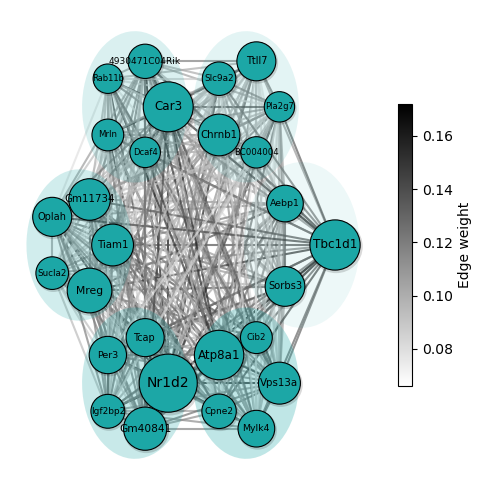

In [15]:
# -------------------------
# 1. Single node color
# -------------------------
node_color_single = "#1CA7A6"   # turquoise tone
ellipse_color_base = "#1CA7A6"

# -------------------------
# 2. Plot
# -------------------------
fig, ax = plt.subplots(figsize=(5, 5))

# ---- SHADOW LAYER ----
shadow_offset = np.array([0.05, -0.05])
shadow_pos = {k: np.array(v) + shadow_offset for k, v in pos.items()}
shadow_sizes = [s * 1.12 for s in node_sizes]

nx.draw_networkx_nodes(
    subgraph,
    shadow_pos,
    node_size=shadow_sizes,
    node_color="black",
    alpha=0.15,
    linewidths=0,
    ax=ax
)

# ---- EDGES (weighted grayscale) ----
nx.draw_networkx_edges(
    subgraph,
    pos,
    edge_color=edge_colors,
    width=1.5,
    alpha=0.7,
    ax=ax
)

# ---- MAIN NODES (single color) ----
nx.draw_networkx_nodes(
    subgraph,
    pos,
    node_size=node_sizes,
    node_color=node_color_single,
    edgecolors="black",
    linewidths=0.8,
    ax=ax
)
sm = cm.ScalarMappable(cmap=edge_cmap, norm=edge_norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, shrink=0.6)
cbar.set_label("Edge weight")
# -------------------------
# 3. Confidence Ellipses per Community
# -------------------------
def draw_confidence_ellipse(x, y, ax, alpha=0.15):
    if len(x) < 3:
        return

    cov = np.cov(x, y)
    lambda_, v = np.linalg.eig(cov)
    lambda_ = np.sqrt(lambda_)

    ell = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=lambda_[0]*4,
        height=lambda_[1]*4,
        angle=np.rad2deg(np.arctan2(*v[:,0][::-1])),
        facecolor=ellipse_color_base,
        edgecolor="none",
        alpha=alpha
    )
    ax.add_patch(ell)

# Different transparency levels per community
communities = sorted(set(nx.get_node_attributes(subgraph, 'community').values()))

for i, comm in enumerate(communities):
    nodes_in_comm = [n for n in subgraph.nodes()
                     if subgraph.nodes[n]['community'] == comm]

    coords = np.array([pos[n] for n in nodes_in_comm])
    draw_confidence_ellipse(
        coords[:, 0],
        coords[:, 1],
        ax,
        alpha=0.08 + i * 0.04   # subtle variation
    )

# -------------------------
# 4. Labels
# -------------------------
for i, node in enumerate(node_list):
    x, y = pos[node]
    ax.text(
        x, y,
        node,
        fontsize=6 + deg_norm[i] * 4,
        ha="center",
        va="center",
        zorder=10
    )

ax.axis("off")

plt.tight_layout()
plt.savefig(
    os.path.join(base_path, "top_5_percentile_nodes_clustered_clean.tiff"),
    dpi=300,
    bbox_inches="tight",
    transparent=True
)
plt.show()

{'4930471C04Rik': 25.769516071243956, 'BC004004': 23.92722648980896, 'Rab11b': 22.812902420773824, 'Mrln': 24.159368371322714, 'Igf2bp2': 25.48373130637824, 'Gm40841': 32.312005937777876, 'Mreg': 33.5862876113842, 'Slc9a2': 25.25740750592259, 'Dcaf4': 23.39603032594074, 'Sorbs3': 29.598264250202618, 'Oplah': 29.10388226797955, 'Ttll7': 29.026598119321562, 'Tcap': 28.3445947459785, 'Nr1d2': 46.73893994665222, 'Tiam1': 31.21987633407475, 'Tbc1d1': 38.58621156112555, 'Gm11734': 31.006029550394228, 'Vps13a': 31.31280226063255, 'Car3': 38.314103687812896, 'Per3': 27.83714425712987, 'Cpne2': 25.8439783633077, 'Cib2': 24.217271334075996, 'Sucla2': 24.709494980328024, 'Atp8a1': 37.83320639657906, 'Mylk4': 27.382306858166835, 'Chrnb1': 31.127869078140286, 'Aebp1': 27.315129445063214, 'Pla2g7': 23.33606245058914}


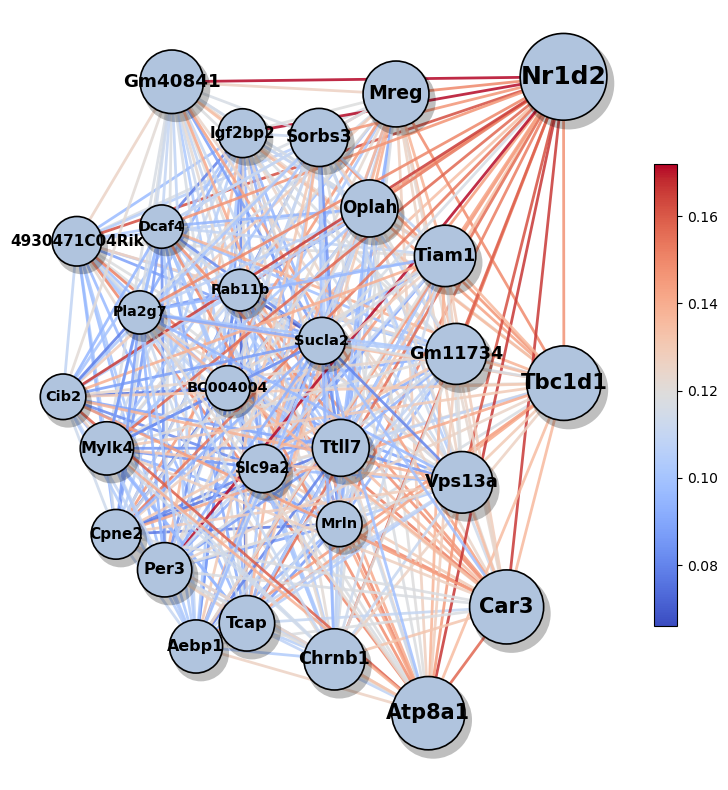

In [13]:
# -------------------------
# 1. Node WEIGHTED degree → normalized
# -------------------------
weighted_degrees = dict(G.degree(subgraph.nodes(), weight="weight"))
print(weighted_degrees)

deg_vals = np.array(
    [weighted_degrees[n] for n in subgraph.nodes()]
).reshape(-1, 1)

scaler = MinMaxScaler()
deg_norm = scaler.fit_transform(deg_vals).flatten()

# Node sizes (scaled by weighted degree)
node_sizes = 900 + deg_norm * 3000


# -------------------------
# 2. Edge colors from weights
# -------------------------
edges = list(subgraph.edges(data=True))
edge_weights = np.array([d.get("weight", 0) for _, _, d in edges])

edge_norm = colors.Normalize(edge_weights.min(), edge_weights.max())
edge_cmap = cm.coolwarm
edge_colors = edge_cmap(edge_norm(edge_weights))


# -------------------------
# 3. Layout (stable + spread)
# -------------------------
pos = nx.kamada_kawai_layout(subgraph)
pos = {k: v * 2.2 for k, v in pos.items()}

# 🔁 MIRROR HORIZONTALLY (LEFT ↔ RIGHT)
pos = {k: np.array([-v[0], v[1]]) for k, v in pos.items()}


# -------------------------
# 4. Plot
# -------------------------
fig, ax = plt.subplots(figsize=(8, 8))

# ---- SHADOW LAYER ----
shadow_offset = np.array([0.04, -0.04])
shadow_pos = {k: v + shadow_offset for k, v in pos.items()}
shadow_sizes = [s * 1.12 for s in node_sizes]

nx.draw_networkx_nodes(
    subgraph,
    shadow_pos,
    node_size=shadow_sizes,
    node_color="black",
    alpha=0.25,
    linewidths=0,
    ax=ax
)

# ---- EDGES ----
nx.draw_networkx_edges(
    subgraph,
    pos,
    edge_color=edge_colors,
    width=2.0,
    alpha=0.85,
    ax=ax
)

# ---- MAIN NODES ----
nx.draw_networkx_nodes(
    subgraph,
    pos,
    node_size=node_sizes,
    node_color="#B0C4DE",
    edgecolors="black",
    linewidths=1.2,
    ax=ax
)

# ---- LABELS (scaled by degree) ----
label_sizes = 10 + deg_norm * 8
node_list = list(subgraph.nodes())

for i, node in enumerate(node_list):
    x, y = pos[node]
    ax.text(
        x, y,
        node,
        fontsize=label_sizes[i],
        weight="bold",
        ha="center",
        va="center",
        zorder=10
    )

ax.axis("off")

# -------------------------
# 5. Edge colorbar
# -------------------------
sm = cm.ScalarMappable(cmap=edge_cmap, norm=edge_norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.6)

plt.tight_layout()
plt.show()


## extract the edgelist as gene ids


In [14]:
# Extract ALL edges from full graph G
all_edges = []
for u, v, data in G.edges(data=True):
    all_edges.append([u, v, data.get('weight', 1.0)])   # keep weight if present

# Convert to DataFrame
all_edgelist_df = pd.DataFrame(all_edges, columns=["Node1", "Node2", "Weight"])

print(all_edgelist_df)
print("Total number of edges in full graph:", len(all_edgelist_df))

# Save full edgelist
all_edgelist_path = os.path.join(base_path, "full_graph_edgelist.tsv")
all_edgelist_df.to_csv(all_edgelist_path, sep="\t", index=False)

print("Saved full graph edgelist to:", all_edgelist_path)

                    Node1   Node2    Weight
0      ENSMUSG00000085133  Tceal5  0.050581
1      ENSMUSG00000085133    Sord  0.050941
2      ENSMUSG00000085133  Slc9a2  0.051031
3      ENSMUSG00000085133  Camk2d  0.070939
4      ENSMUSG00000085133  Sucla2  0.067561
...                   ...     ...       ...
16894                Tcap   Tiam1  0.104950
16895                Tcap    Narf  0.063580
16896                 Hlf   Tiam1  0.106115
16897                 Hlf    Narf  0.054290
16898               Tiam1    Narf  0.084921

[16899 rows x 3 columns]
Total number of edges in full graph: 16899
Saved full graph edgelist to: /home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/outputs/network_analysis/turquoise/full_graph_edgelist.tsv


## extract the nodelist


In [91]:
node_list= G.nodes()
print(node_list)
print("Total number of nodes in full graph:", len(node_list))

['ENSMUSG00000085133', 'ENSMUSG00000125576', 'ENSMUSG00000142490', 'Gm17167', 'Gm54215', 'Fitm2', 'Abhd11', 'Pld5', 'Fam118b', 'Apeh', 'Acsl4', 'Prr15', 'Arhgap21', 'Gm43658', 'Zhx2', 'Hibadh', 'Rp2', 'Tpd52', 'Suclg1', 'Ndufa8', 'Nek6', 'Eif4e2', 'Trim72', 'Rhot2', 'Got2', 'Nipsnap2', 'Gsto1', 'Maoa', 'Prdx5', 'Ube2n', 'Ifngr2', 'Coq10a', 'Slc25a4', 'Idh3b', 'Clu', 'Gm45457', 'Gm35315', 'Nim1k', 'Atl2', 'Rpia', 'Fam161a', 'Pdp1', 'Marchf4', 'Fnip1', 'Sfxn5', 'Mras', 'Tsc22d3', 'Ezh2', 'Mthfr', 'Dyrk2', 'Mrps18a', 'Slc7a8', 'Mfn1', 'Sdha', 'Zfas1', 'Zfp597', 'Mak16', 'Cacng1', 'Psmd7', 'Psmc2', 'Psmd1', 'Fuca1', 'Inpp4a', 'Pde8a', 'Gm72135', '2310015D24Rik', 'Myhas', 'Pdzd7', 'Lysmd4', 'Zfp385b', 'Psmd13', 'Lynx1', 'Ccdc134', 'Psmb6', 'Stard3', 'Bmal1', 'Miga2', 'Chchd3', 'Wfs1', 'Coq8a', 'Slc41a1', 'Nsun2', 'Pnkd', 'Slc41a3', 'Relt', 'Gm64932', 'Pdzd8', 'Klhl40', 'Lrrc30', 'Fbh1', 'Nfil3', 'Per2', 'Exoc6', 'Amer1', 'Bex1', 'Ark2n', 'Leo1', 'Phlda3', 'Coro2b', 'Serpine1', 'Elf2', 'Slc2

In [92]:
# Convert node_list to pandas DataFrame
df_nodes = pd.DataFrame({"Node": node_list})

# Save as TSV
node_list_path = os.path.join(base_path, "full_graph_nodelist.tsv")
df_nodes.to_csv(node_list_path, sep="\t", index=False)

print(f"Saved node list to: {node_list_path}")



Saved node list to: /home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/outputs/network_analysis/turquoise/full_graph_nodelist.tsv


## Compute communities

In [15]:
# ---------------------------------------------------------
# 1. COMPUTE LOUVAIN COMMUNITIES FOR MULTIPLE RESOLUTIONS
# ---------------------------------------------------------
for resolution in np.arange(0.1, 2.1, 0.1):
    communities = nx.community.louvain_communities(
        G,
        resolution=round(resolution, 2),  # avoid float precision issues
        seed=42
    )
    
    print(f"Resolution = {resolution:.1f} → Number of communities = {len(communities)}")


Resolution = 0.1 → Number of communities = 3
Resolution = 0.2 → Number of communities = 3
Resolution = 0.3 → Number of communities = 4
Resolution = 0.4 → Number of communities = 4
Resolution = 0.5 → Number of communities = 4
Resolution = 0.6 → Number of communities = 6
Resolution = 0.7 → Number of communities = 6
Resolution = 0.8 → Number of communities = 5
Resolution = 0.9 → Number of communities = 6
Resolution = 1.0 → Number of communities = 7
Resolution = 1.1 → Number of communities = 8
Resolution = 1.2 → Number of communities = 12
Resolution = 1.3 → Number of communities = 16
Resolution = 1.4 → Number of communities = 21
Resolution = 1.5 → Number of communities = 27
Resolution = 1.6 → Number of communities = 32
Resolution = 1.7 → Number of communities = 37
Resolution = 1.8 → Number of communities = 41
Resolution = 1.9 → Number of communities = 48
Resolution = 2.0 → Number of communities = 56


In [16]:
# compute communities at resolution 1.1
communities = nx.community.louvain_communities(
    G, resolution=1.1,
    seed=42
)   

In [17]:

# ---------------------------------------------------------
# 2. SAVE COMMUNITY LIST TO CSV
# ---------------------------------------------------------
# Build a node → community dictionary
node_to_comm = {}
for idx, comm in enumerate(communities):
    for node in comm:
        node_to_comm[node] = idx

# Convert to DataFrame
df_comm = pd.DataFrame(list(node_to_comm.items()),
                       columns=["Node", "Community"])

print(df_comm)
# Save to CSV
community_csv = os.path.join(base_path, "louvain_communities.csv")
df_comm.to_csv(community_csv, sep="\t", index=False)

print("Saved Louvain communities to:", community_csv)


                   Node  Community
0               Gm17167          0
1               Gm54215          0
2    ENSMUSG00000142490          0
3                 Prr15          1
4               Herpud1          1
..                  ...        ...
548              Zfp808          7
549                 Hlf          7
550              Map2k6          7
551                Clpx          7
552               Paqr7          7

[553 rows x 2 columns]
Saved Louvain communities to: /home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/outputs/network_analysis/turquoise/louvain_communities.csv


In [12]:
# Convert communities into a dict of lists
comm_dict = {}
for idx, comm in enumerate(communities):
    comm_dict[f"Community_{idx}"] = list(comm)

# Convert to DataFrame (columns = communities, rows = genes)
df_wide = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in comm_dict.items()]))

print(df_wide)

# Save wide format
community_wide_path = os.path.join(base_path, "louvain_communities_wide.tsv")
df_wide.to_csv(community_wide_path, sep="\t", index=False)

print("Saved wide-format Louvain community table to:", community_wide_path)

            Community_0 Community_1 Community_2 Community_3 Community_4  \
0    ENSMUSG00000142490     Herpud1        Wfs1         Clu         Vcp   
1               Gm54215         Pir        Mfn1         Cpe       Hip1r   
2               Gm17167     Aldh1a1      Ndufa8       Golm2       Srpra   
3                   NaN       Peli2     Atp5f1d     Slc38a4       Ces1d   
4                   NaN        E2f2    Nipsnap2       Eif3i        Usp4   
..                  ...         ...         ...         ...         ...   
96                  NaN         NaN         NaN         NaN         NaN   
97                  NaN         NaN         NaN         NaN         NaN   
98                  NaN         NaN         NaN         NaN         NaN   
99                  NaN         NaN         NaN         NaN         NaN   
100                 NaN         NaN         NaN         NaN         NaN   

       Community_5 Community_6 Community_7  
0           Lrp2bp      Lrrc30     Gm42737  
1        

In [101]:
genes_of_interest = [
    "Per2", "Per3", "Cry1", "Nr1d2", "Clock"
]

target_gene = "Igf2bp2"


In [102]:
import networkx as nx

n_runs = 1000
resolution = 1.0

circadian_together = 0
circadian_plus_igf2bp2 = 0

for seed in range(n_runs):
    communities = nx.community.louvain_communities(
        G,
        weight="weight",
        resolution=resolution,
        seed=seed
    )

    for community in communities:
        # check if all circadian genes are together
        if all(gene in community for gene in genes_of_interest):
            circadian_together += 1

            # now check if Igf2bp2 is also in that same community
            if target_gene in community:
                circadian_plus_igf2bp2 += 1

            # only count once per run
            break


In [103]:
print(f"Total Louvain runs: {n_runs}")
print(f"Runs where circadian genes cluster together: {circadian_together}")

if circadian_together > 0:
    frac = circadian_plus_igf2bp2 / circadian_together
    print(
        f"Runs where Igf2bp2 joins that circadian module: "
        f"{circadian_plus_igf2bp2} "
        f"({frac:.3f})"
    )
else:
    print("Circadian genes never clustered together — check resolution or graph.")


Total Louvain runs: 1000
Runs where circadian genes cluster together: 870
Runs where Igf2bp2 joins that circadian module: 870 (1.000)
